# LECTURE 6
**Topic:** Aliasing  
**Textbook References:** Section 1.6

---

## Key Points

- Two CT sinusoids at frequencies $f$ and $f'$ sampled at rate $f_s$ produce the same DT sequence when $f \pm f' = kf_s$ for integer $k$.
- **Aliasing** = two different CT frequencies appearing identical after sampling.
- If a CT signal has components up to $f_B$ Hz, aliasing is avoided iff $f_s > 2f_B$ (the **Nyquist rate**).


---
## Theory and Examples

### 1–2. Aliasing Between Two Frequencies

Two CT sinusoids at $f$ and $f'$ sampled at $f_s$ give DT frequencies $\Omega=2\pi f/f_s$ and $\Omega'=2\pi f'/f_s$.
They produce the **same DT sinusoid** when $\Omega' = \pm\Omega + 2k\pi$, i.e.:
$$f \pm f' = kf_s \quad \text{for some integer } k$$

### 3. Example: Aliases of f = 150 Hz

With $f_s = 400$ Hz, aliases of $f=150$ Hz:
$$f' = 150 + k(400) \quad \text{and} \quad f' = -150 + k(400)$$

With $f_s = 280$ Hz:
$$f' = 150 + k(280) \quad \text{and} \quad f' = -150 + k(280)$$

**Task:** Find all aliases in $[0, 2000]$ Hz for each case.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Find aliases of f=150 Hz
f = 150
for fs, label in [(400,'fs=400'), (280,'fs=280')]:
    print(f'=== {label} Hz ===')
    aliases = set()
    for k in range(-10,10):
        for sign in [1,-1]:
            fa = sign*f + k*fs
            if 0 <= fa <= 2000:
                aliases.add(fa)
    print(f'  Aliases in [0,2000] Hz: {sorted(aliases)}')
    print()

=== fs=400 Hz ===
  Aliases in [0,2000] Hz: [150, 250, 550, 650, 950, 1050, 1350, 1450, 1750, 1850]

=== fs=280 Hz ===
  Aliases in [0,2000] Hz: [130, 150, 410, 430, 690, 710, 970, 990, 1250, 1270, 1530, 1550, 1810, 1830]



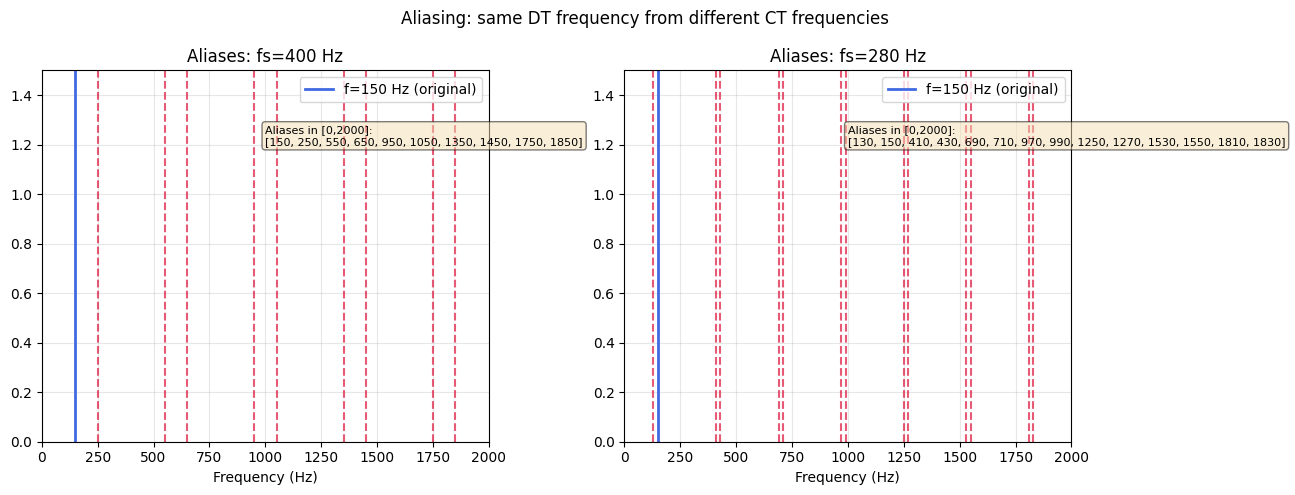

In [2]:
# Visualize aliasing
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (fs, label) in zip(axes, [(400,'fs=400 Hz'), (280,'fs=280 Hz')]):
    f = 150
    aliases = []
    for k in range(-10,10):
        for sign in [1,-1]:
            fa = sign*f + k*fs
            if 0 <= fa <= 2000:
                aliases.append(fa)
    aliases = sorted(set(aliases))

    ax.axvline(f, color='royalblue', lw=2, label=f'f={f} Hz (original)')
    for i, fa in enumerate(aliases):
        if fa != f:
            ax.axvline(fa, color='crimson', lw=1.5, alpha=0.7, ls='--')
    ax.set_xlabel('Frequency (Hz)'); ax.set_title(f'Aliases: {label}')
    ax.set_xlim(0, 2000); ax.set_ylim(0, 1.5)
    ax.legend(); ax.grid(True, alpha=0.3)
    ax.text(0.5, 0.8, f'Aliases in [0,2000]:\n{aliases}', transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Aliasing: same DT frequency from different CT frequencies', fontsize=12)
plt.tight_layout(); plt.show()

---
### 4. Example: Signal Reconstruction from Samples

Given: $x(t)$ has frequency between 600 and 800 Hz, sampled at $f_s=400$ to give:
$$x[n] = 4.2\cos(0.75\pi n - 0.3)$$

Step 1: $\Omega=0.75\pi \Rightarrow f = (0.375)(400) = 150$ Hz (outside given range).

Step 2: From the previous example, alias of 150 Hz in $[600,800]$ is $f'=650$ Hz.

Step 3: $x(t) = 4.2\cos(1300\pi t + 0.3)$

**Question:** Why is the initial phase inverted?

**Answer:** $f'=-150+1\cdot 400=250$? No. Let's use $f'=-f+k\cdot f_s$: $-150+400=250$... Actually $f'=650$ comes from $f'=150+400=550$? No—$-150+800=650$. That uses $k=2$: $-150+2(400)=650$.
The negative alias formula $f'=-f+kf_s$ with $k=2$: DT freq $\Omega'=2\pi(650/400)$ ... but $\Omega'=2\pi\cdot 650/400 - 2\pi = 2\pi(0.375)=0.75\pi$ which equals original BUT with **negated phase**.
That's why the phase flips: $\cos(\Omega n - \phi)$ becomes $\cos(-\Omega n + \phi)=\cos(\Omega n - \phi)$... more precisely, the sign reversal in the frequency alias formula flips the phase sign.


=== Reconstruction of x(t) from x[n] ===
  From omega=0.75pi: f_naive = 150.0 Hz (not in [600,800])
  Alias in [600,800]: f prime=650.0 Hz  (sign=-1, k=2)
  Negative alias => phase flips: -0.3 -> 0.3

Verify: max|x[n] - x_150(n/fs)| = 1.14e-13
        max|x[n] - x_650(n/fs)| = 9.83e-13


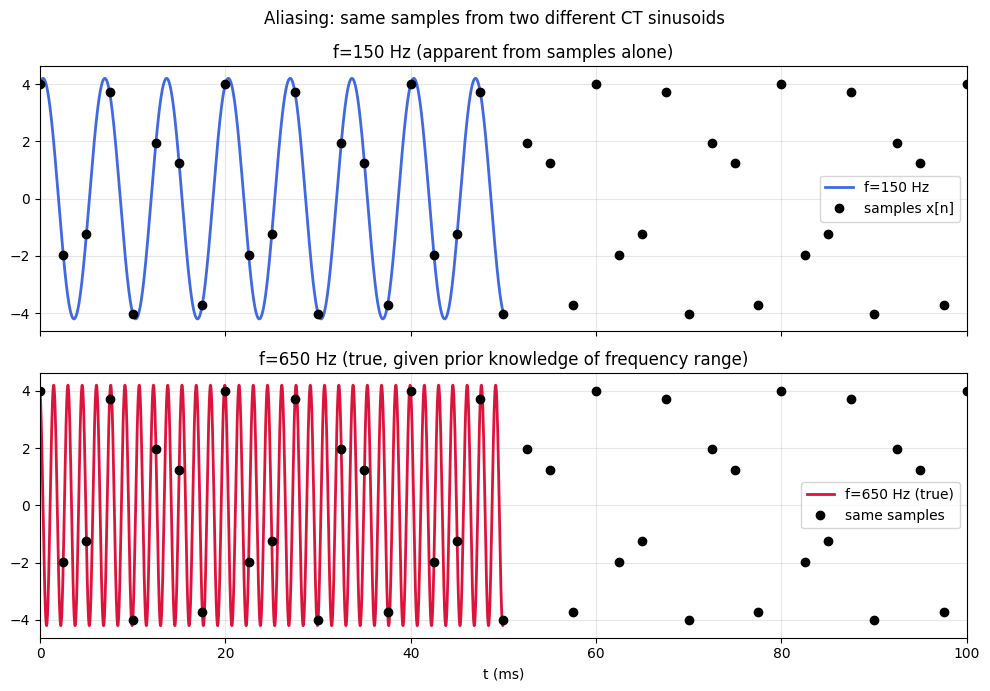

In [15]:
# Signal reconstruction demo
fs = 400; omega_dn = 0.75*np.pi; phi_dn = -0.3
print('=== Reconstruction of x(t) from x[n] ===')
f_naive = (omega_dn/(2*np.pi)) * fs
print(f'  From omega=0.75pi: f_naive = {f_naive:.1f} Hz (not in [600,800])')

# Find alias in [600,800]
f_target = f_naive
for k in range(-5,5):
    for sign in [1,-1]:
        fa = sign*f_target + k*fs
        if 600 <= fa <= 800:
            print(f'  Alias in [600,800]: f prime={fa} Hz  (sign={sign}, k={k})')
            if sign == -1:
                print(f'  Negative alias => phase flips: {phi_dn} -> {-phi_dn}')

# Verify
n = np.arange(0,100)
x_dn = 4.2*np.cos(0.75*np.pi*n - 0.3)
# Both 150 Hz and 650 Hz sampled at 400 give same x[n]
t = n/fs
x_150 = 4.2*np.cos(2*np.pi*150*t - 0.3)
x_650 = 4.2*np.cos(2*np.pi*650*t + 0.3)  # phase flipped
print(f'\nVerify: max|x[n] - x_150(n/fs)| = {np.max(np.abs(x_dn-x_150)):.2e}')
print(f'        max|x[n] - x_650(n/fs)| = {np.max(np.abs(x_dn-x_650)):.2e}')

fig, axes = plt.subplots(2,1,figsize=(10,7),sharex=True)
t_ct = np.linspace(0, 0.05, 2000)
axes[0].plot(t_ct*1000, 4.2*np.cos(2*np.pi*150*t_ct-0.3), 'royalblue', lw=2, label='f=150 Hz')
axes[0].plot(t*1000, x_dn, 'ko', ms=6, label='samples x[n]'); axes[0].legend(); axes[0].grid(True,alpha=0.3)
axes[0].set_title('f=150 Hz (apparent from samples alone)')
axes[1].plot(t_ct*1000, 4.2*np.cos(2*np.pi*650*t_ct+0.3), 'crimson', lw=2, label='f=650 Hz (true)')
axes[1].plot(t*1000, x_dn, 'ko', ms=6, label='same samples'); axes[1].legend(); axes[1].grid(True,alpha=0.3)
axes[1].set_title('f=650 Hz (true, given prior knowledge of frequency range)')
axes[1].set_xlabel('t (ms)')
for ax in axes:
    ax.set_xlim(0, 100)

plt.suptitle('Aliasing: same samples from two different CT sinusoids', fontsize=12)
plt.tight_layout(); plt.show()

---
### 5. Why Aliased Signals Cannot Be Distinguished

If a sample sequence $x[n]$ could have come from **either** $f=150$ Hz **or** $f=650$ Hz (both produce identical samples), then you cannot reconstruct the original CT signal from samples alone without additional information (like knowing the frequency range).

### 6. The Nyquist Rate

If a CT signal has frequency components only in $[0, f_B]$ Hz, aliasing is avoided when $f_s > 2f_B$.  
The minimum rate $2f_B$ is the **Nyquist rate**.

**Why?** Aliases of $[0,f_B]$ under sampling are bands at $[-f_B+kf_s, f_B+kf_s]$ for each $k$. These bands overlap (causing aliasing) unless the gap $f_s - 2f_B > 0$, i.e., $f_s > 2f_B$.

**Task:** Show that when $f_s = 2f_B - \delta$ (slightly below Nyquist), frequencies $f_B-\delta/2$ and $f_s-(f_B-\delta/2)$ are aliases.


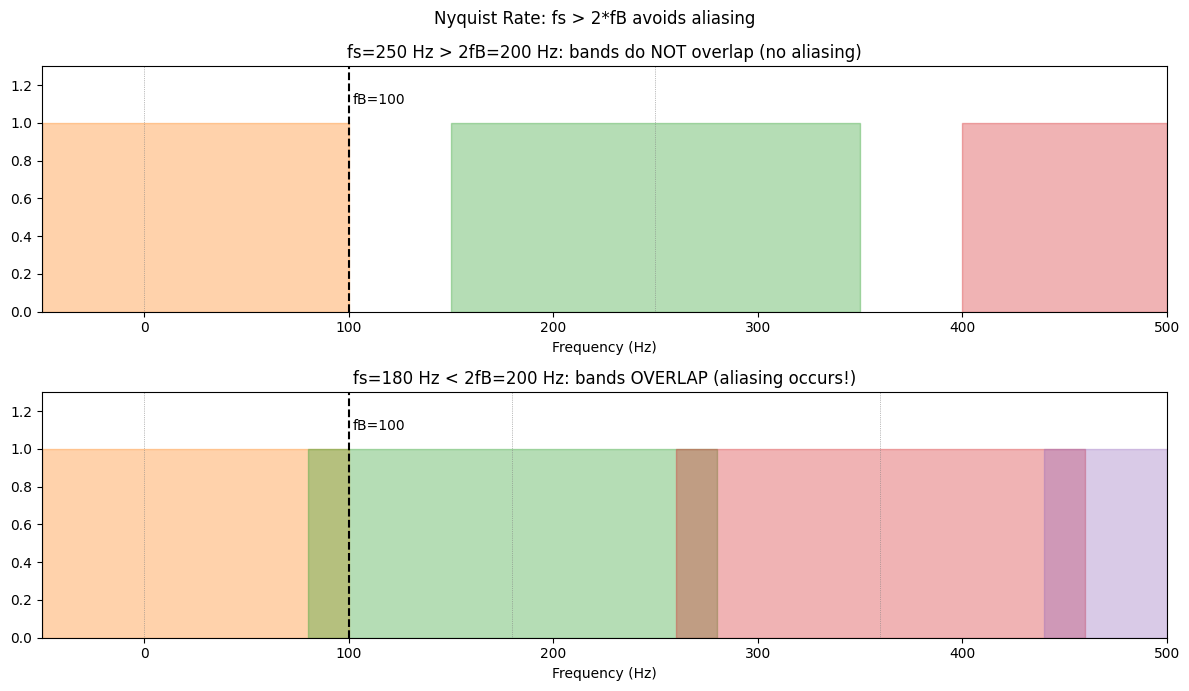

fs = 2fB - delta = 180 Hz
f1 = fB - delta/2 = 90.0 Hz
f2 = fs - f1 = 90.0 Hz
Check: f1 + f2 = 180.0 = fs = 180  => aliases!
Both f1 and f2 are in [0,fB]=[0,100]: f1=90.0? True, f2=90.0? True


In [4]:
# Nyquist rate visualization
fB = 100; delta = 20

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# Case 1: fs > 2fB (no aliasing)
fs1 = 2*fB + 50  # 250 Hz
ax = axes[0]
colors = plt.cm.tab10(range(6))
for k in range(-1,3):
    low = -fB + k*fs1; high = fB + k*fs1
    col = colors[(k+1)%6]
    ax.fill_between([max(low,-50),min(high,500)], [0,0],[1,1], alpha=0.35, color=col)
    ax.axvline(k*fs1, color='gray', lw=0.5, ls=':')
ax.set_xlim(-50,500); ax.set_ylim(0,1.3)
ax.set_title(f'fs={fs1} Hz > 2fB={2*fB} Hz: bands do NOT overlap (no aliasing)')
ax.set_xlabel('Frequency (Hz)')
ax.axvline(fB, color='black', lw=1.5, ls='--'); ax.text(fB+2, 1.1, f'fB={fB}')

# Case 2: fs < 2fB (aliasing)
fs2 = 2*fB - delta  # 180 Hz
ax = axes[1]
for k in range(-1,4):
    low = -fB + k*fs2; high = fB + k*fs2
    col = colors[(k+1)%6]
    ax.fill_between([max(low,-50),min(high,500)], [0,0],[1,1], alpha=0.35, color=col)
    ax.axvline(k*fs2, color='gray', lw=0.5, ls=':')
ax.set_xlim(-50,500); ax.set_ylim(0,1.3)
ax.set_title(f'fs={fs2} Hz < 2fB={2*fB} Hz: bands OVERLAP (aliasing occurs!)')
ax.set_xlabel('Frequency (Hz)')
ax.axvline(fB, color='black', lw=1.5, ls='--'); ax.text(fB+2, 1.1, f'fB={fB}')

plt.suptitle('Nyquist Rate: fs > 2*fB avoids aliasing', fontsize=12)
plt.tight_layout(); plt.show()

# Task: show aliasing when fs = 2fB - delta
fs_under = 2*fB - delta
f1 = fB - delta/2
f2 = fs_under - f1
print(f'fs = 2fB - delta = {fs_under} Hz')
print(f'f1 = fB - delta/2 = {f1} Hz')
print(f'f2 = fs - f1 = {f2} Hz')
print(f'Check: f1 + f2 = {f1+f2} = fs = {fs_under}  => aliases!')
print(f'Both f1 and f2 are in [0,fB]=[0,{fB}]: f1={f1}? {0<=f1<=fB}, f2={f2}? {0<=f2<=fB}')

---
## Summary

| Formula | Meaning |
|---|---|
| $f \pm f' = kf_s$ | $f$ and $f'$ are aliases at rate $f_s$ |
| $f_s > 2f_B$ | Nyquist condition to avoid aliasing |

### Mistakes to Avoid
1. Thinking aliasing only happens at high frequencies — it can occur any time $f_s < 2f$.
2. Forgetting that aliasing is **irreversible** — once aliased, you cannot recover the original signal without extra information.
3. Confusing the Nyquist rate ($2f_B$) with the Nyquist frequency ($f_B = f_s/2$).
